# "Analisis Pola Arus Lalu Lintas dan Tingkat Kemacetan Perkotaan berbasis IOT"
## Kelompok 6:
## 5027261050    Nabil Farhan Shidqi
## 5027261071    Mohammad Dimaz Zaujim Bahij
## 5027261120    Amirah Hasna Salsabila
#### Topik : Smart City

Menurut kami, grafik ini dibuat untuk mengetahui dan menganalisis rata-rata kecepatan kendaraan pada waktu yang berbeda, baik pada weekday (hari kerja) maupun weekend (akhir pekan). Dengan membandingkan kecepatan kendaraan pada jam-jam tertentu, kami dapat melihat pola perubahan kondisi lalu lintas, seperti kapan kendaraan cenderung melaju lebih lambat atau lebih cepat. Dengan melihat perubahan kecepatan tersebut, kami dapat mengetahui pola lalu lintas dan mengidentifikasi waktu-waktu yang berpotensi mengalami perlambatan, sehingga dapat menjadi bahan untuk mengantisipasi kemungkinan terjadinya kemacetan di kemudian hari.

### @ berapa rata2 kecepatan kendaraan di saat weekend maupun weekday?
### @ rata2 kecepatan kendaraan paling rendah maupun paling tinggi terjadi pada jam berapa saja?

In [19]:
import pandas as pd

df = pd.read_csv('smart_city_traffic_mobility.csv')
print(df.shape) # (jumlah baris, jumlah kolom)
df.head()

(204000, 47)


,record_id,city_zone,road_id,intersection_id,latitude,longitude,road_type,lanes,speed_limit,vehicle_count,...,traffic_camera_count,iot_sensor_health,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate,congestion_level
0,REC_0000001,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,162,...,1,Optimal,60,18,0,162.0,16.8,39.14,8.53,Low
1,REC_0000002,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,150,...,1,Optimal,60,18,0,150.0,18.4,36.09,7.83,Low
2,REC_0000003,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,186,...,1,Optimal,60,18,0,186.0,20.7,44.01,9.39,Low
3,REC_0000004,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,162,...,1,Optimal,60,18,0,162.0,17.8,38.47,8.24,Low
4,REC_0000005,Financial District,RD_206,INT_001,40.757551,-73.990504,Local Street,2,40,168,...,1,Optimal,60,18,0,168.0,17.3,40.28,8.71,Low


Setiap baris pada tabel tersebut mewakili kendaraan yang terekam oleh kamera lalulintas

# Deskripsi & Kamus Data
## Sumber Data: Kaggle - CityFlow Traffic IoT (Public Domain / CC0)
## Pengumpul Data: Dikumpulkan otomatis dari jaringan sensor telemetri IoT dan kamera lalu lintas pintar.

| Kolom | Arti | Jenis Variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| timestamp | Waktu kendaraan melintas | Data waktu (datetime) | Interval | YYYY-MM-DD HH:MM:SS | 2026-01-01 00:00:00 |
| average_speed | Rata-rata kecepatan kendaraan | Kuantitatif kontinu | Rasio | km/jam | 32.5 |
| hour | Jam kendaraan melintas | Kuantitatif diskrit | Interval | Jam (0–23) | 12 |
| is_weekend | Menunjukkan apakah hari termasuk weekend atau bukan | Kualitatif nominal | Nominal | – | 0 = Weekday, 1 = Weekend |

In [21]:
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   record_id                   204000 non-null  object 
 1   city_zone                   204000 non-null  object 
 2   road_id                     204000 non-null  object 
 3   intersection_id             204000 non-null  object 
 4   latitude                    204000 non-null  float64
 5   longitude                   204000 non-null  float64
 6   road_type                   204000 non-null  object 
 7   lanes                       204000 non-null  int64  
 8   speed_limit                 204000 non-null  int64  
 9   vehicle_count               204000 non-null  int64  
 10  average_speed               204000 non-null  float64
 11  heavy_vehicle_count         204000 non-null  int64  
 12  motorcycle_count            204000 non-null  int64  
 13  public_transpo

0

@ kolom yang banyak kosong = -
@ tipe data yang salah = -
@ nilai yang tidak masuk akal = -

In [23]:
df['is_weekend'].value_counts()
df['is_weekend'].value_counts(normalize=True) * 100

is_weekend
0    71.764706
1    28.235294
Name: proportion, dtype: float64

In [65]:
speed = df["average_speed"]

speed.mean() # rata2
speed.median() # nilai tengah
speed.mode()[0] # modus
speed.var() # varian
speed.std() # standar deviasi
speed.quantile(0.25) # kuartil 1
speed.quantile(0.75) # kuartil 3

jam = df["hour"]

jam.mean()
jam.median()
jam.mode()[0]
jam.var()
jam.std()
jam.quantile(0.25)
jam.quantile(0.75)

df.describe().style.set_properties(
    subset=['average_speed','hour'],
    **{
        'background-color': '#FFF2A8',
        'font-weight': 'bold',
        'border': '2px solid #E6C200'
    }
)

,latitude,longitude,lanes,speed_limit,vehicle_count,average_speed,heavy_vehicle_count,motorcycle_count,public_transport_count,traffic_density,queue_length,average_wait_time,hour,day_of_week,is_weekend,is_holiday,rush_hour,temperature,rainfall_mm,visibility_km,air_quality_index,nearby_school,nearby_hospital,nearby_market,construction_activity,parking_occupancy,public_event,accident_reported,traffic_camera_count,signal_cycle_seconds,green_light_duration,emergency_vehicle_detected,traffic_flow_rate,congestion_score,emission_estimate,fuel_waste_estimate
count,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000,204000.000000
mean,40.716219,-74.004859,2.750000,56.700000,749.585907,42.235582,36.969373,74.478319,21.959971,90.660393,121.470659,12.149789,11.500000,3.000000,0.282353,0.029632,0.209314,15.000706,0.399935,9.581334,72.517485,0.230000,0.150000,0.440000,0.079549,40.710226,0.039309,0.019750,2.370000,75.174118,39.070775,0.020049,749.585907,50.007555,257.416941,72.496380
std,0.044876,0.044211,0.726294,17.609984,754.542368,22.214697,41.987095,81.489370,25.773987,85.277658,230.578569,23.270389,6.922204,1.988205,0.450145,0.169571,0.406820,7.347122,1.500300,0.906593,20.343502,0.420834,0.357072,0.496388,0.270594,25.557559,0.194329,0.139140,1.128320,26.080578,27.153351,0.140168,754.542368,38.798606,339.096417,111.519920
min,40.636691,-74.083673,2.000000,40.000000,54.000000,5.000000,1.000000,3.000000,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.800000,0.000000,0.500000,20.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,1.000000,60.000000,18.000000,0.000000,54.000000,5.400000,12.740000,2.710000
25%,40.676753,-74.041839,2.000000,40.000000,171.000000,27.700000,7.000000,16.000000,4.000000,20.800000,6.800000,0.700000,5.750000,1.000000,0.000000,0.000000,0.000000,8.300000,0.000000,9.500000,58.000000,0.000000,0.000000,0.000000,0.000000,16.900000,0.000000,0.000000,1.000000,60.000000,18.000000,0.000000,171.000000,15.200000,41.250000,8.950000
50%,40.721824,-74.001825,3.000000,60.000000,308.000000,40.000000,16.000000,32.000000,9.000000,35.700000,19.100000,1.900000,11.500000,3.000000,0.000000,0.000000,0.000000,15.000000,0.000000,9.900000,72.000000,0.000000,0.000000,0.000000,0.000000,40.100000,0.000000,0.000000,2.000000,60.000000,23.000000,0.000000,308.000000,25.100000,74.070000,16.020000
75%,40.753293,-73.972532,3.000000,60.000000,1208.000000,58.100000,56.000000,117.000000,33.000000,175.100000,173.800000,17.200000,17.250000,5.000000,1.000000,0.000000,0.000000,21.700000,0.000000,10.000000,87.000000,0.000000,0.000000,1.000000,0.000000,63.100000,0.000000,0.000000,3.000000,120.000000,84.000000,0.000000,1208.000000,100.000000,376.840000,98.480000
max,40.790642,-73.928036,4.000000,90.000000,3162.000000,90.000000,246.000000,468.000000,156.000000,378.500000,10111.600000,1174.500000,23.000000,6.000000,1.000000,1.000000,1.000000,33.100000,31.600000,10.000000,152.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,4.000000,120.000000,84.000000,1.000000,3162.000000,100.000000,9717.220000,4066.070000


In [67]:
df["is_weekend"].value_counts()

is_weekend
0    146400
1     57600
Name: count, dtype: int64

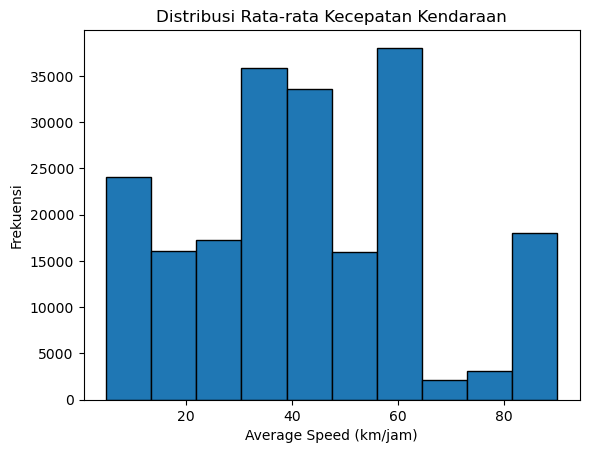

In [27]:
import matplotlib.pyplot as plt

plt.hist(df['average_speed'], bins=10, edgecolor='black')
plt.title("Distribusi Rata-rata Kecepatan Kendaraan")
plt.xlabel("Average Speed (km/jam)")
plt.ylabel("Frekuensi")
plt.show()

Q1 : 27.7
Q3 : 58.1
IQR : 30.400000000000002
Batas bawah : -17.900000000000002
Batas atas : 103.7
Jumlah pencilan : 0


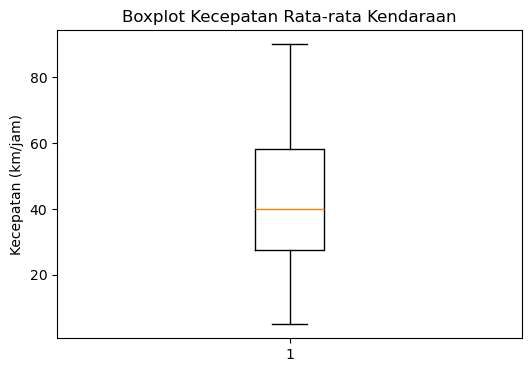

In [18]:
# Mengambil kolom average_speed
import pandas as pd
df = pd.read_csv('smart_city_traffic_mobility.csv')
kolom = df["average_speed"]

# Menghitung Q1, Q3, dan IQR
Q1 = kolom.quantile(0.25)
Q3 = kolom.quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Mengambil data pencilan
outlier = df[(df["average_speed"] < batas_bawah) | (df["average_speed"] > batas_atas)]

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Batas bawah :", batas_bawah)
print("Batas atas :", batas_atas)
print("Jumlah pencilan :", len(outlier))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df["average_speed"], vert=True)

plt.title("Boxplot Kecepatan Rata-rata Kendaraan")
plt.ylabel("Kecepatan (km/jam)")

plt.show()

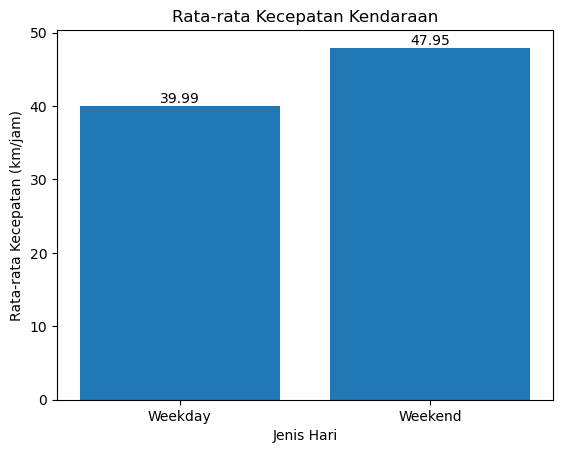

In [77]:
import matplotlib.pyplot as plt

weekday = df[df["is_weekend"] == 0]["average_speed"].mean()
weekend = df[df["is_weekend"] == 1]["average_speed"].mean()

hari = ["Weekday", "Weekend"]
rata_rata = [weekday, weekend]

plt.bar(hari, rata_rata)

plt.title("Rata-rata Kecepatan Kendaraan")
plt.xlabel("Jenis Hari")
plt.ylabel("Rata-rata Kecepatan (km/jam)")

# Menampilkan nilai di atas batang
for i, nilai in enumerate(rata_rata):
    plt.text(i, nilai, f"{nilai:.2f}", ha="center", va="bottom")

plt.show()

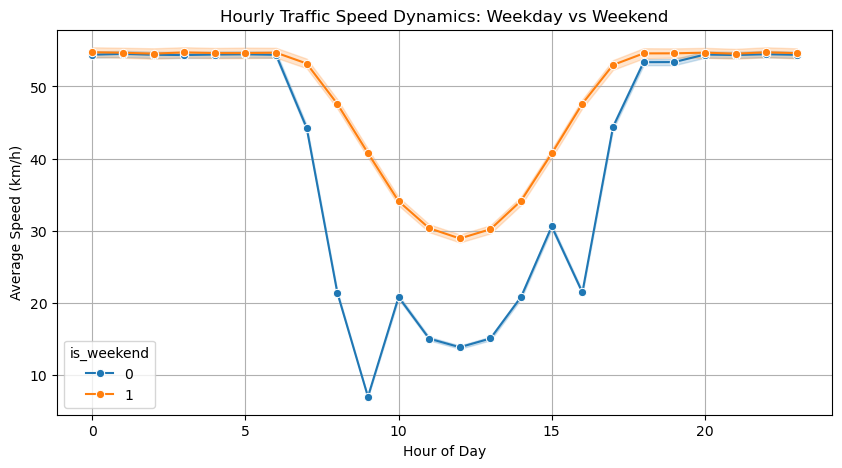

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('smart_city_traffic_mobility.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='average_speed', hue='is_weekend', marker='o')
plt.title('Hourly Traffic Speed Dynamics: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average Speed (km/h)')
plt.grid(True)
plt.show()

# Kesimpulan

### berapa rata2 kecepatan kendaraan di saat weekend maupun weekday?
### >> Rata2 saat weekend = +- 47,95 | Rata2 saat Weekday = +- 39,99
### rata2 kecepatan kendaraan paling rendah maupun paling tinggi terjadi pada jam berapa saja?
### >> Rata2 kecepatan kendaraan paling rendah terjadi pada jam +-9 | Rata2 kecepatan kendaraan paling tinggi terjadi pada jam 20.00-06.00
### Temuan menarik :
1. Tidak ada pencilan 
2. Rata-rata kecepatan weekday berbeda dengan weekend
3. Terdapat jam tertentu dengan rata-rata kecepatan paling rendah
4. Terdapat jam tertentu dengan rata-rata kecepatan paling tinggi
### keterbatasan data :
1. Data hanya berasal dari periode atau lokasi tertentu
2. Hanya menganalisis beberapa variabel, belum faktor lain.
### pertanyaan lanjutan : 
1. Apakah kondisi cuaca juga dapat mempengaruhi rata-rata kecepatan kendaraan?.

| Alat | Dipakai untuk | Yang kami pelajari |
| ------- | -------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| ChatGPT | Membantu memahami error dan fungsi pada kode Python | Memahami penyebab error serta fungsi beberapa perintah Python |
| ChatGPT | Memahami konsep IQR, aturan 1,5 × IQR, dan boxplot | Memahami cara mengidentifikasi pencilan dan membaca boxplot |
| ChatGPT | Meminta contoh sintaks visualisasi menggunakan `matplotlib` | Memahami cara membuat bar chart dan boxplot |
| ChatGPT | Mendiskusikan aspek yang dapat diperhatikan dari hasil analisis data | Memahami hal-hal yang perlu diperiksa dari hasil perhitungan dan visualisasi |
| ChatGPT | Membantu mengecek pemahaman terhadap hasil perhitungan | Memastikan langkah analisis dan istilah yang digunakan sudah dipahami dengan benar |
| ChatGPT | Membantu menghighlight kolom yang diinginkan pada tabel deskripsi data | Cara menghighlight kolom pada tabel deskripsi data |
| ChatGPT | Membantu untuk menampilkan nilai di atas batang pada diagram batang | cara menampilkan nilai diatas diagram batang |